In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-08 10:58:01.163237


# Train scVI model

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse, csr_matrix
import scvi
import numpy as np
from collections import Counter
import anndata as ad
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


## Set paths, import data

In [ ]:
sys.path.append(str(Path.cwd().resolve().parents[1]))
from config.paths import BASE_DIR

input_dir = BASE_DIR / 'data/h5ad/export_01/01b_filter'
scvi_dir = BASE_DIR / 'scvi/models'
output_dir = BASE_DIR / 'data/h5ad/export_02/02a_scvi'

output_dir.mkdir(parents=True, exist_ok=True)

In [5]:
path_480   = input_dir / "adata-480.h5ad"
path_475 = input_dir / "adata-475.h5ad"

In [6]:
adata = sc.read_h5ad(path_475)
bdata = sc.read_h5ad(path_480)

## Prepare adata

In [7]:
# Save counts layer for scVI and downstream processing
adata.X = adata.layers['counts'].copy()
bdata.X = bdata.layers['counts'].copy()

In [8]:
for n, a in zip(["adata", "bdata"], [adata, bdata]):
    if not issparse(a.X):
        a.X = csr_matrix(a.X)
        print(f"Converted {n} to sparse CSR")

In [9]:
adata.X[:5, :5].toarray()

array([[ 0.,  1.,  0.,  0.,  0.],
       [ 4.,  0., 25., 31.,  0.],
       [ 2.,  0.,  5., 21.,  0.],
       [ 0.,  0.,  0., 33.,  0.],
       [ 0.,  1.,  0.,  1.,  0.]], dtype=float32)

In [10]:
bdata.X[:5, :5].toarray()

array([[ 0.,  1.,  0.,  0.,  0.],
       [ 4.,  0., 25., 31.,  0.],
       [ 2.,  0.,  5., 21.,  0.],
       [ 0.,  0.,  0., 33.,  0.],
       [ 0.,  1.,  0.,  1.,  0.]], dtype=float32)

In [11]:
print('adata.X is sparse:', issparse(adata.X))
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

adata.X is sparse: True
adata.X has only whole numbers: True


# scVI

In [12]:
def train_scvi_model(adata, model_name, scvi_dir, output_dir, latent_key_suffix=""):
    print(f"\n Training {model_name}")

    # Setup for scVI
    scvi.model.SCVI.setup_anndata(
        adata,
        layer="counts",
        batch_key="slide_id"
    )

    # Initialize model
    model = scvi.model.SCVI(
        adata,
        gene_likelihood="nb"
    )

    # Train model
    model.train(accelerator = 'gpu', early_stopping = True) # updated 12/2

    # Save model
    model_save_dir = os.path.join(scvi_dir, model_name)
    model.save(model_save_dir)

    # Plot ELBO loss curves
    plt.plot(model.history["elbo_train"], label="Train ELBO Loss")
    plt.plot(model.history["elbo_validation"], label="Validation ELBO Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"{model_name} SCVI Training Loss")
    plt.tight_layout()
    plt.show()

    # Add latent representation
    latent_key = f"X_scVI_{model_name}"
    adata.obsm[latent_key] = model.get_latent_representation(adata).astype(np.float32)

    # Save AnnData
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.join(output_dir, f"{model_name}_adata-scvi.h5ad")
    adata.write_h5ad(filename, compression="gzip")

    print(f"Saved model + latent to {filename} ({latent_key})")

    return model, adata


 Training ModelA_475


/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightni

Epoch 54/54: 100%|██████████| 54/54 [07:51<00:00,  8.51s/it, v_num=1, train_loss_step=274, train_loss_epoch=284]

`Trainer.fit` stopped: `max_epochs=54` reached.


Epoch 54/54: 100%|██████████| 54/54 [07:51<00:00,  8.73s/it, v_num=1, train_loss_step=274, train_loss_epoch=284]


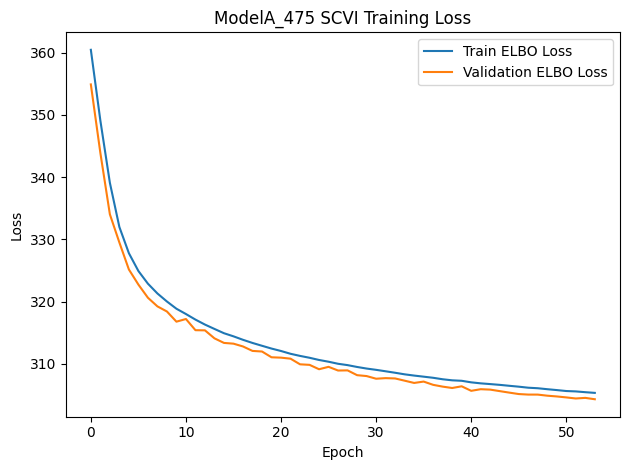

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightni

Saved model + latent to /home/workspace/projects/drg/data/h5ad/export_02/02a_scvi/ModelA_475_adata-scvi.h5ad (X_scVI_ModelA_475)

 Training ModelB_480
Epoch 54/54: 100%|██████████| 54/54 [07:41<00:00,  8.49s/it, v_num=1, train_loss_step=287, train_loss_epoch=288]

`Trainer.fit` stopped: `max_epochs=54` reached.


Epoch 54/54: 100%|██████████| 54/54 [07:41<00:00,  8.55s/it, v_num=1, train_loss_step=287, train_loss_epoch=288]


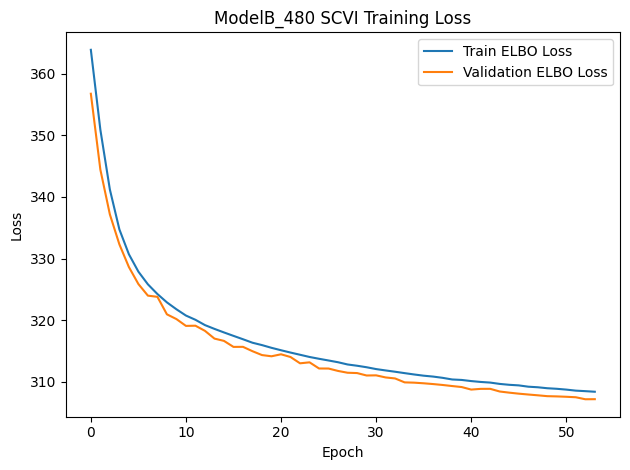

Saved model + latent to /home/workspace/projects/drg/data/h5ad/export_02/02a_scvi/ModelB_480_adata-scvi.h5ad (X_scVI_ModelB_480)


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

(,
 AnnData object with n_obs × n_vars = 147036 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels'
     uns: '_scvi_uuid', '_scvi_manager_uuid'
     obsm: 'spatial', 'X_scVI_ModelB_480'
     layers: 'counts')

In [13]:
train_scvi_model(adata,  "ModelA_475", scvi_dir, output_dir)
train_scvi_model(bdata, "ModelB_480", scvi_dir, output_dir)

## Session info

In [14]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
